In [5]:

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

**Objective**
The objective of this study is to group customers into different clusters based on similarities in age, annual income, and spending score using clustering algorithms such as K-Means Clustering.
The study helps businesses identify different customer categories for strategic decision-making and personalized marketing.


In [6]:
# Import numerical computation library
import numpy as np

# Import pandas for dataset handling
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for advanced visualization
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [1]:
from google.colab import files
df = files.upload()

Saving Data1.csv to Data1.csv


In [7]:
#Read exel file
df = pd.read_csv('Data1.csv')
# Display first  rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:\n", df.columns)

# Display data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (200, 5)

Column Names:
 Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Data Types:

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [10]:
# Selecting numerical features only
X = df.drop(['Gender'], axis=1)

# Display first 5 rows
X.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [11]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale the dataset
X_scaled = scaler.fit_transform(X)

# Display scaled data shape
print(X_scaled.shape)

(200, 4)


In [12]:
# Import KMeans
from sklearn.cluster import KMeans

# Create empty list for WCSS
wcss = []

# Run loop for different k values
for i in range(1, 11):

    # Create KMeans model
    kmeans = KMeans(n_clusters=i, random_state=42)

    # Fit model
    kmeans.fit(X_scaled)

    # Append inertia value
    wcss.append(kmeans.inertia_)


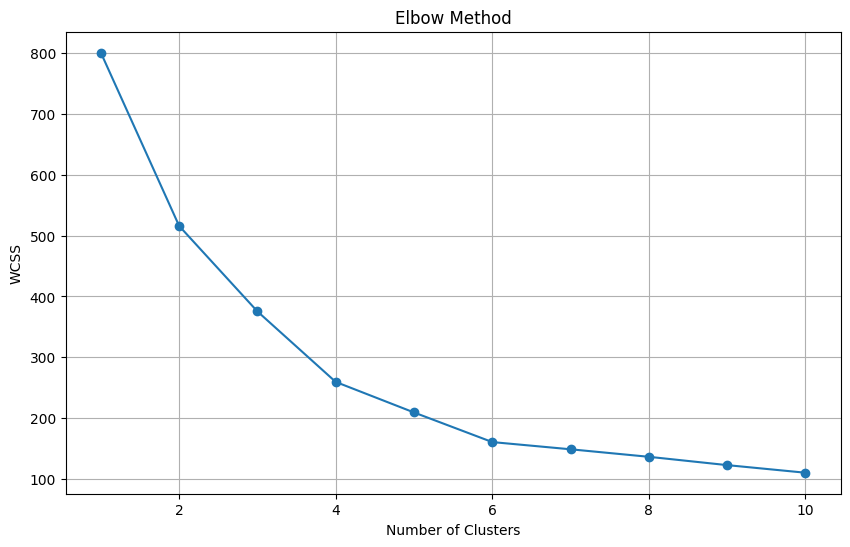

In [13]:
# Plot elbow graph
plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [14]:
# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column into dataset
df['Cluster'] = clusters

In [15]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data
pca_components = pca.fit_transform(X_scaled)

# Create new dataframe
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

# Add cluster column
pca_df['Cluster'] = clusters

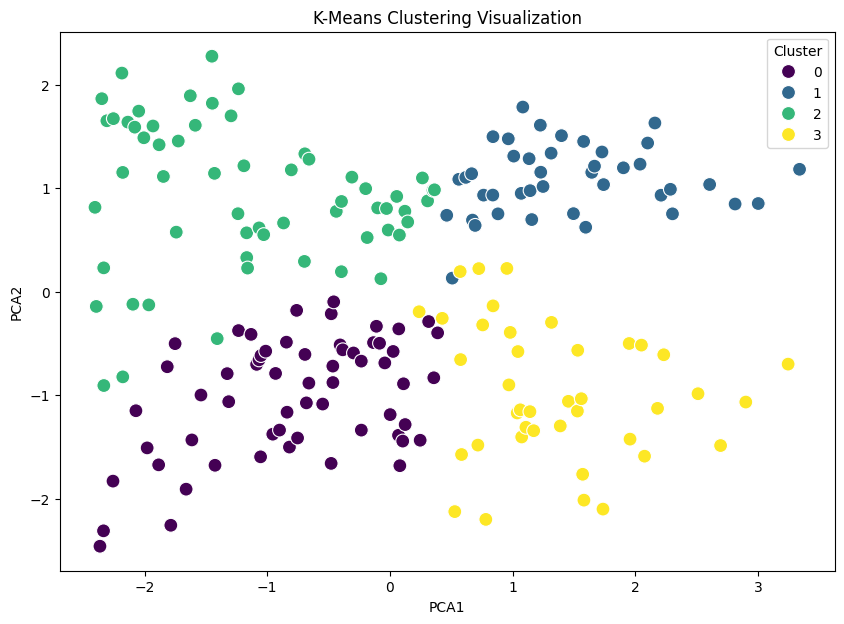

In [16]:
# Plot clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

plt.title('K-Means Clustering Visualization')

plt.show()

In [18]:
# Cluster-wise average values
cluster_mean = df.groupby('Cluster').mean(numeric_only=True)

# Display analysis
print(cluster_analysis)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         69.350000  54.766667           47.933333               41.783333
1        160.048780  32.731707           85.634146               80.902439
2         50.610169  25.949153           38.779661               58.067797
3        159.775000  40.275000           85.925000               19.750000


In [19]:
# CLUSTER CENTERS
# ----------------------------------------

# Display cluster centers
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

# Add cluster number
cluster_centers.index.name = 'Cluster Number'

# Display cluster centers
print("Cluster Centers:\n")
print(cluster_centers)

Cluster Centers:

                CustomerID        Age  Annual Income (k$)  \
Cluster Number                                              
0                69.350000  54.766667           47.933333   
1               160.048780  32.731707           85.634146   
2                50.610169  25.949153           38.779661   
3               159.775000  40.275000           85.925000   

                Spending Score (1-100)  
Cluster Number                          
0                            41.783333  
1                            80.902439  
2                            58.067797  
3                            19.750000  


In [20]:
# ===========================================
# PCA CLUSTER VISUALIZATION
# ===========================================

# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data into 2 dimensions
pca_components = pca.fit_transform(X_scaled)

# Create dataframe for PCA
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1', 'PCA2']
)

# Add cluster labels
pca_df['Cluster'] = clusters

# Display first 5 rows
print(pca_df.head())

       PCA1      PCA2  Cluster
0 -2.403924  0.816423        2
1 -2.348416  1.866763        2
2 -2.393558 -0.142008        2
3 -2.307126  1.653214        2
4 -2.332853  0.230933        2


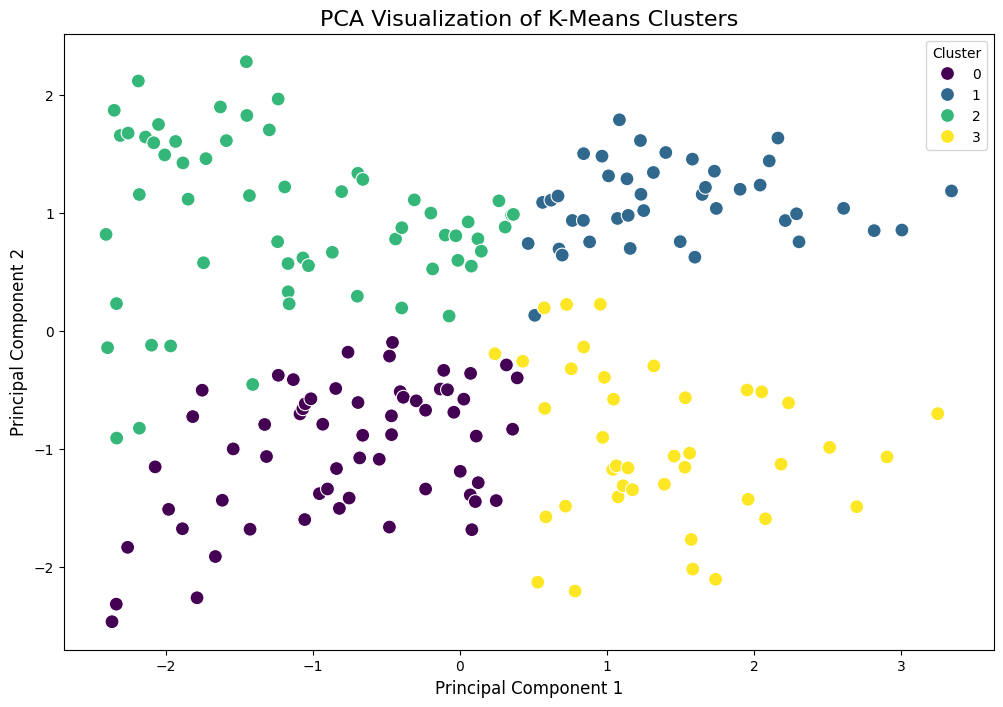

In [21]:
# ===========================================
# PCA SCATTER PLOT
# ===========================================

# Set figure size
plt.figure(figsize=(12,8))

# Create scatter plot
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

# Plot title
plt.title('PCA Visualization of K-Means Clusters', fontsize=16)

# X-axis label
plt.xlabel('Principal Component 1', fontsize=12)

# Y-axis label
plt.ylabel('Principal Component 2', fontsize=12)

# Show legend
plt.legend(title='Cluster')

# Show graph
plt.show()

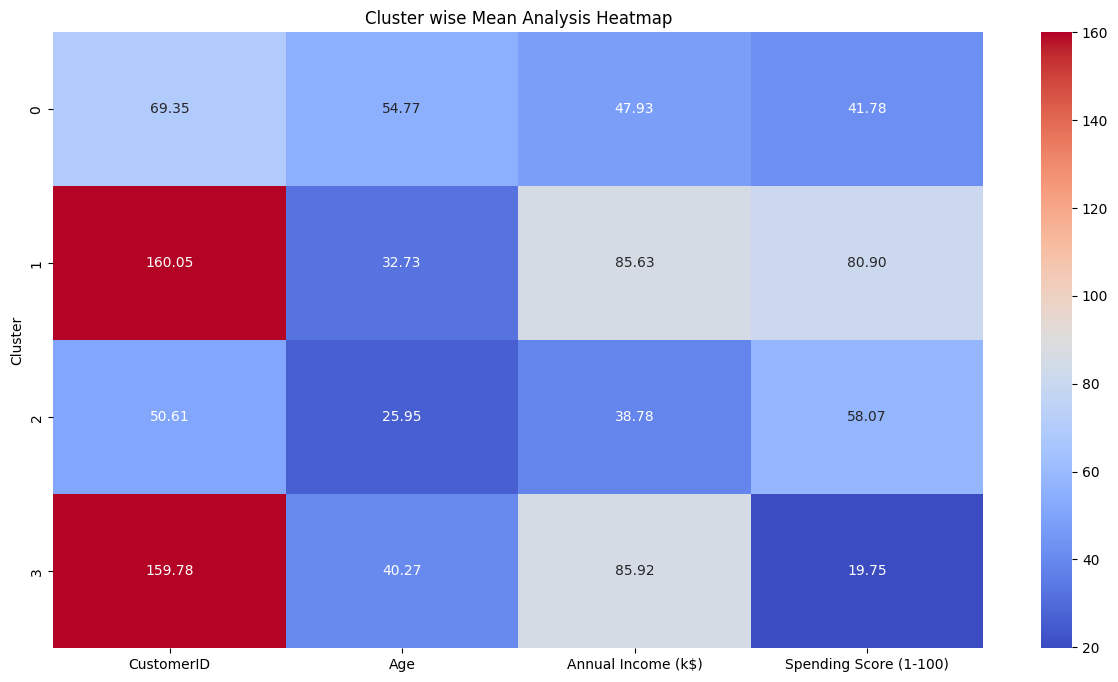

In [22]:
# ===========================================
# HEATMAP OF CLUSTER MEANS
# ===========================================

# Set figure size
plt.figure(figsize=(15,8))

# Create heatmap
sns.heatmap(
    cluster_mean,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Title
plt.title('Cluster wise Mean Analysis Heatmap')

# Show graph
plt.show()

Conclusion – K-Means Clustering

This study applied K-Means Clustering to segment customers based on Age, Annual Income (k$), and Spending Score (1–100).

The clustering analysis successfully divided customers into four distinct clusters, each representing different customer profiles.

Cluster 0

Average Age = 54.77 years
Annual Income = 47.93 k$
Spending Score = 41.78

Cluster 1

Average Age = 32.73 years
Annual Income = 85.63 k$
Spending Score = 80.90

Cluster 2

Average Age = 25.95 years
Annual Income = 38.78 k$
Spending Score = 58.07

Cluster 3

Average Age = 40.28 years
Annual Income = 85.93 k$
Spending Score = 19.75

This cluster represents high-income customers with very low spending scores. Although they have strong purchasing power, they spend less and may require personalized marketing strategies to increase engagement

The PCA results (PCA1 and PCA2) helped visualize customer groups, This made cluster separation easier to understand and interpret.

Overall, K-Means Clustering effectively identified meaningful customer segments within the dataset. The analysis shows that customers differ significantly in age, income, and spending behavior.